In [1]:
import matplotlib.pyplot as plt
import numpy as np 
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst, frames
from sunpy.time import TimeRange
from astropy import units as u

In [2]:
times = [t.center for t in TimeRange("2025-01-01", "2026-01-01").split(600)]

In [3]:
solo = get_horizons_coord("solo", times)
psp = get_horizons_coord("psp", times)
bepi= get_horizons_coord("bepi", times)

INFO: Obtained JPL HORIZONS location for Solar Orbiter (spacecraft) (-144) [sunpy.coordinates.ephemeris]
INFO: Obtained JPL HORIZONS location for Parker Solar Probe (spacecraft) (-96) [sunpy.coordinates.ephemeris]
INFO: Obtained JPL HORIZONS location for BepiColombo (Spacecraft) (-121) [sunpy.coordinates.ephemeris]


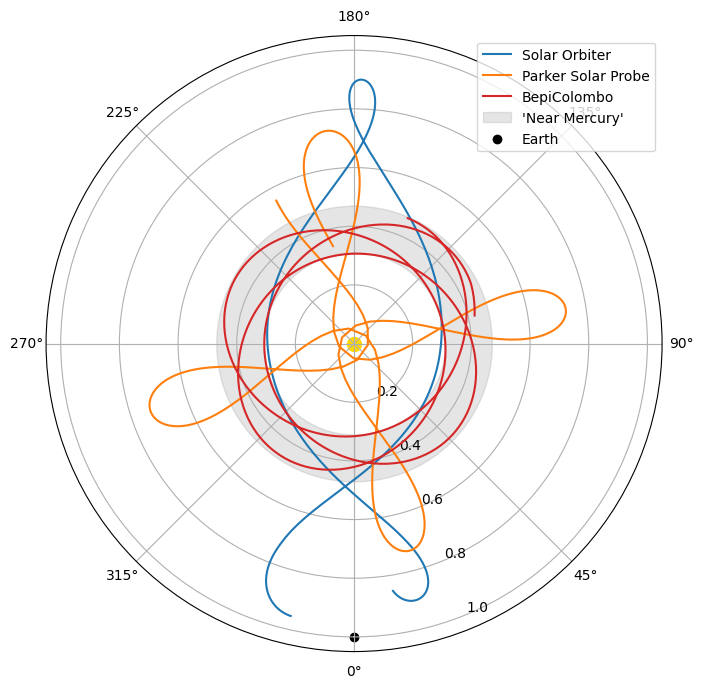

In [7]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection="polar")

ax.plot(solo.lon.to(u.rad), solo.radius.to(u.AU), label="Solar Orbiter")
ax.plot(psp.lon.to(u.rad), psp.radius.to(u.AU), label="Parker Solar Probe")
ax.plot(bepi.lon.to(u.rad), bepi.radius.to(u.AU), label="BepiColombo", color="C3")


ax.fill_between(
    np.linspace(0, 2 * np.pi, 100),
    0.31,
    0.47,
    label=r"'Near Mercury'",
    color="grey",
    alpha=0.2
)
ax.scatter(0, 1, color='black', label="Earth") # Earth
ax.scatter(0, 0, color='gold', s=100) # Sun
ax.legend()

ax.set_theta_zero_location('S')

plt.savefig("../../figures/spacecraft-trajectories.pdf", format="pdf")